# SeaFreeze — Python API examples

This notebook runs a worked example for **every public function** of the
`seafreeze` package:

| Function | Purpose |
|---|---|
| `getProp` | Thermodynamic & elastic properties of H₂O phases / aqueous NaCl |
| `whichphase` | Most stable phase at given (P, T[, m]) |
| `phasenum2phase` | Integer phase index → material name |
| `phases` | Dict of supported materials |
| `phase_range` | Knot-domain bounds of a Gibbs spline |
| `phase_lines` | Equilibrium (P, T) curve between two phases |
| `wpd` | Full H₂O water phase diagram plot |
| `rho2P` | Invert the EOS: pressure from density & temperature |

> **Run this notebook from the `Python/` directory** so that `import seafreeze`
> resolves to the in-repo package and the bundled splines are found.

In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

import seafreeze as sf

# whichphase / phase_lines / wpd evaluate the splines slightly outside their
# knot domain near phase boundaries; that is expected and produces NaN there.
# Quiet the (harmless) LBFTD extrapolation warnings so outputs stay readable.
# A filter is used (rather than setLevel) because getProp resets the lbftd
# logger level on every call, but leaves filters untouched.
logging.getLogger('lbftd').addFilter(lambda record: record.levelno >= logging.ERROR)

print("SeaFreeze loaded from:", sf.__file__)

SeaFreeze loaded from: /Users/baptiste/Documents/GitHub/SeaFreeze/Python/seafreeze/__init__.py


## 0. Supported phases

`sf.phases` maps each material code to its descriptor. Ice phases (`Ih`, `II`,
`III`, `V`, `VI`, `VII_X_French`), liquid water (`water1` recommended for
200–355 K up to 2300 MPa; `water2` and `water_IAPWS95` for HP / comparison), and
aqueous NaCl (`NaClaq` — the recommended stitched LP+HP 2026 spline — plus its
`NaClaq_LP`, `NaClaq_HP`, and `NaClaq_5GPa_2024` variants).

In [2]:
list(sf.phases.keys())

['Ih',
 'II',
 'III',
 'V',
 'VI',
 'VII_X_French',
 'water1',
 'water2',
 'water_IAPWS95',
 'NaClaq',
 'NaClaq_LP',
 'NaClaq_HP',
 'NaClaq_5GPa_2024']

## 1. `getProp` — thermodynamic & elastic properties

Input `PTm` can be **scatter** (1-D object array of `(P, T)` / `(P, T, m)`
tuples) or a **grid** (`np.array([P_vec, T_vec], dtype=object)`). Pressure is in
MPa, temperature in K, molality in mol/kg. The result is a `SimpleNamespace`
whose attributes are the computed properties.

**(a) Single scatter point — ice VI at 900 MPa, 255 K**

In [3]:
PT = np.empty((1,), dtype=object)
PT[0] = (900, 255)
out = sf.getProp(PT, 'VI')
print(f"rho = {out.rho.flat[0]:.3f} kg/m^3")
print(f"Vp  = {out.Vp.flat[0]:.1f} m/s   (compressional-wave velocity)")
print(f"Vs  = {out.Vs.flat[0]:.1f} m/s   (shear-wave velocity)")

rho = 1356.072 kg/m^3
Vp  = 4548.9 m/s   (compressional-wave velocity)
Vs  = 2320.7 m/s   (shear-wave velocity)


**(b) Several scatter points — liquid water1**

In [4]:
PT = np.empty((3,), dtype=object)
PT[0] = (441.0858, 313.95)
PT[1] = (478.7415, 313.96)
PT[2] = (444.8285, 313.78)
out = sf.getProp(PT, 'water1')
print("H (enthalpy, J/kg) at each (P,T):", np.round(out.H, 2))

H (enthalpy, J/kg) at each (P,T): [528453.8  557033.54 530652.78]


**(c) Grid evaluation — ice V over a P×T grid**

Rows correspond to pressures, columns to temperatures.

In [5]:
P = np.arange(400, 501, 10)   # MPa
T = np.arange(240, 250.1, 1.0) # K
PT = np.array([P, T], dtype=object)
out = sf.getProp(PT, 'V')
print("Helmholtz energy A shape (nP x nT):", out.A.shape)
print("shear modulus (MPa) at first grid point:", round(float(out.shear[0, 0]), 1))

Helmholtz energy A shape (nP x nT): (11, 11)
shear modulus (MPa) at first grid point: 5703.7


**(d) Request only specific properties**

Trailing strings (`*tdvSpec`) restrict the computation to those properties.
Because they come *after* the `path` argument in the signature
`getProp(PTm, phase, path, *tdvSpec)`, the splines path must be passed
explicitly first — here via `sf.seafreeze.defpath` (the bundled default).

In [6]:
PT = np.empty((1,), dtype=object)
PT[0] = (200.0, 280.0)
out = sf.getProp(PT, 'water1', sf.seafreeze.defpath, 'rho', 'Cp', 'vel')
print("rho =", round(float(out.rho.flat[0]), 3), "kg/m^3")
print("Cp  =", round(float(out.Cp.flat[0]), 3), "J/kg/K")
print("vel =", round(float(out.vel.flat[0]), 3), "m/s")

rho = 1079.364 kg/m^3
Cp  = 3845.546 J/kg/K
vel = 1777.812 m/s


**(e) Aqueous NaCl — grid with a molality axis `[P, T, m]`**

NaClaq adds solution properties such as water activity `aw`.

In [7]:
P = np.arange(10, 201, 20)    # MPa
T = np.arange(280, 320.1, 10)  # K
m = np.array([1.0])            # mol/kg
PTm = np.array([P, T, m], dtype=object)
out = sf.getProp(PTm, 'NaClaq')
print("rho shape (nP x nT x nm):", out.rho.shape)
print("rho at (P=10, T=280, m=1):", round(float(out.rho[0, 0, 0]), 2), "kg/m^3")
print("aw  at (P=10, T=280, m=1):", round(float(out.aw[0, 0, 0]), 5))

rho shape (nP x nT x nm): (10, 5, 1)
rho at (P=10, T=280, m=1): 1045.42 kg/m^3
aw  at (P=10, T=280, m=1): 0.96732


## 2. `whichphase` + `phasenum2phase` — stable phase

`whichphase` returns integer phase indices (0 = liquid, 1 = Ih, 2 = II, 3 = III,
5 = V, 6 = VI; `NaN` outside all parametrizations). `phasenum2phase` converts an
index back to a material name.

**(a) Single point and (b) several scatter points**

In [8]:
PT = np.empty((1,), dtype=object)
PT[0] = (900, 255)
out = sf.whichphase(PT)
print("Phase at (900 MPa, 255 K):", sf.phasenum2phase(out[0]))

PT = np.empty((3,), dtype=object)
PT[0] = (100, 200)
PT[1] = (400, 250)
PT[2] = (1000, 300)
out = sf.whichphase(PT)
for pt, pn in zip(PT, out):
    print(pt, "->", sf.phasenum2phase(pn))

Phase at (900 MPa, 255 K): VI
(100, 200) -> Ih
(400, 250) -> V
(1000, 300) -> VI


**(c) NaCl freezing-point-depression map — `solute='NaCl'`, grid `[P, T, m]`**

In [9]:
P = np.arange(0, 500, 25)
T = np.arange(240, 300, 3.0)
m = np.full(P.size, 2.0)   # 2 mol/kg NaCl
PTm = np.array([P, T, m], dtype=object)
out = sf.whichphase(PTm, solute='NaCl')
print("phase-index grid shape (nP x nT):", out.shape)
present = sorted({int(v) for v in np.unique(out) if np.isfinite(v)})
print("phases present:", [(p, sf.phasenum2phase(p)) for p in present])

phase-index grid shape (nP x nT): (20, 20)
phases present: [(1, 'Ih'), (2, 'II'), (3, 'III'), (5, 'V')]


## 3. `phase_range` — spline domain bounds

Returns a `PhaseRange(P, T, m)` namedtuple; `m` is `None` for pure phases.

In [10]:
for material in ('Ih', 'water1', 'NaClaq'):
    r = sf.phase_range(material)
    print(f"{material:8s}  P={r.P} MPa  T={r.T} K  m={r.m}")

Ih        P=(0.0, 400.0) MPa  T=(1.0, 300.99999999999983) K  m=None
water1    P=(0.0, 2300.5999999999995) MPa  T=(238.99999999999991, 501.0000000000002) K  m=None
NaClaq    P=(0.0, 10000.999999999998) MPa  T=(229.90000000000006, 501.0000000000002) K  m=(0.0, 7.0)


## 4. `phase_lines` — equilibrium boundary curves

`phase_lines(matA, matB, ...)` returns a `PhaseLineResult` with `.P`, `.T`, a
`.stable` boolean mask, and literature `.triple_points`. Order of the two
materials is symmetric. `segment` selects `'all'`, `'stable'`, or `'meta'`.

**(a) Pure-phase boundary: ice V ↔ liquid water1**

In [11]:
r = sf.phase_lines('V', 'water1', segment='stable')
print(f"{r.matA}-{r.matB}: {r.P.size} points, "
      f"P in [{r.P.min():.1f}, {r.P.max():.1f}] MPa, "
      f"T in [{r.T.min():.2f}, {r.T.max():.2f}] K")

V-water1: 176 points, P in [352.1, 634.1] MPa, T in [256.32, 273.39] K


**(b) NaClaq melting curve at one molality (here Ih ↔ NaClaq, m = 1 mol/kg)**

For the Ih–water1 pure-water boundary we request `segment='all'` and use the
`.stable` mask to draw the stable portion solid and its **metastable extension
dashed**. Note that the NaClaq boundary returned here is the *whole* curve
marked stable — it **includes the metastable range** (the m-dependent triple
points that would delimit it are out of scope in the current port, matching
Matlab v1.1.x), so no separate dashed segment is shown for it.

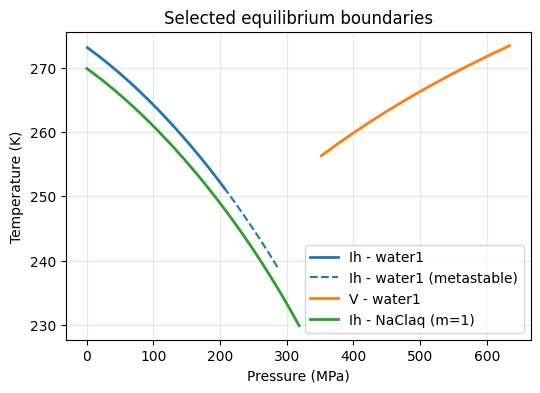

In [12]:
r_ih = sf.phase_lines('Ih', 'water1', segment='all')   # full curve (stable + metastable)
r_v = sf.phase_lines('V', 'water1', segment='stable')
r_nacl = sf.phase_lines('Ih', 'NaClaq', m=1.0)         # whole curve incl. metastable range

fig, ax = plt.subplots(figsize=(6, 4))
# Ih-water1: solid where stable, dashed metastable extension.
# The metastable mask has two disconnected index runs (near-atmospheric end and
# supercooled high-P end); insert NaN breaks so matplotlib does not draw a
# straight connector between them.
ax.plot(r_ih.P[r_ih.stable], r_ih.T[r_ih.stable], '-', lw=2, color='C0',
        label='Ih - water1')
# Show the metastable extension only at pressures at/above the triple point
# (Ih-III-Liquid at ~251 K, 207 MPa) — i.e. the supercooled continuation of the
# melting curve. The spurious low-pressure metastable point near the origin is
# excluded so no straight connector is drawn across the diagram.
P_tp = r_ih.P[r_ih.stable].max()
meta_mask = (~r_ih.stable) & (r_ih.P >= P_tp)
if meta_mask.sum() > 1:
    ax.plot(r_ih.P[meta_mask], r_ih.T[meta_mask], '--', lw=1.5, color='C0',
            label='Ih - water1 (metastable)')
ax.plot(r_v.P, r_v.T, '-', lw=2, color='C1', label='V - water1')
ax.plot(r_nacl.P, r_nacl.T, '-', lw=2, color='C2', label='Ih - NaClaq (m=1)')
ax.set_xlabel('Pressure (MPa)')
ax.set_ylabel('Temperature (K)')
ax.set_title('Selected equilibrium boundaries')
ax.legend()
ax.grid(True, alpha=0.3)
display(fig); plt.close(fig)

## 5. `wpd` — full water phase diagram

`wpd` draws every stable-phase pair and returns a `matplotlib.figure.Figure`.

**(a) Pure water with phase-field labels**

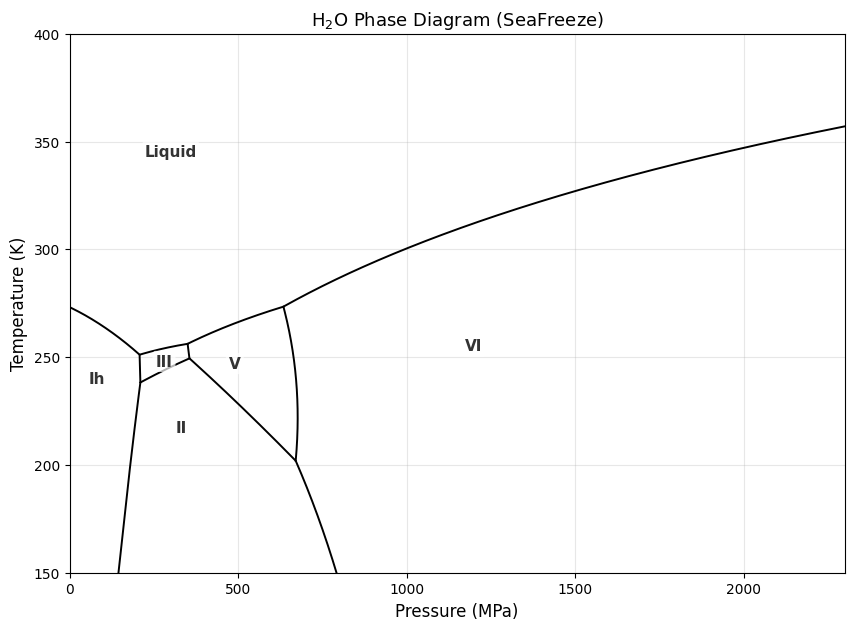

In [13]:
fig = sf.wpd(show_meta=False, phase_labels=True)
display(fig); plt.close(fig)

**(b) With NaCl melting-curve overlay at several molalities**

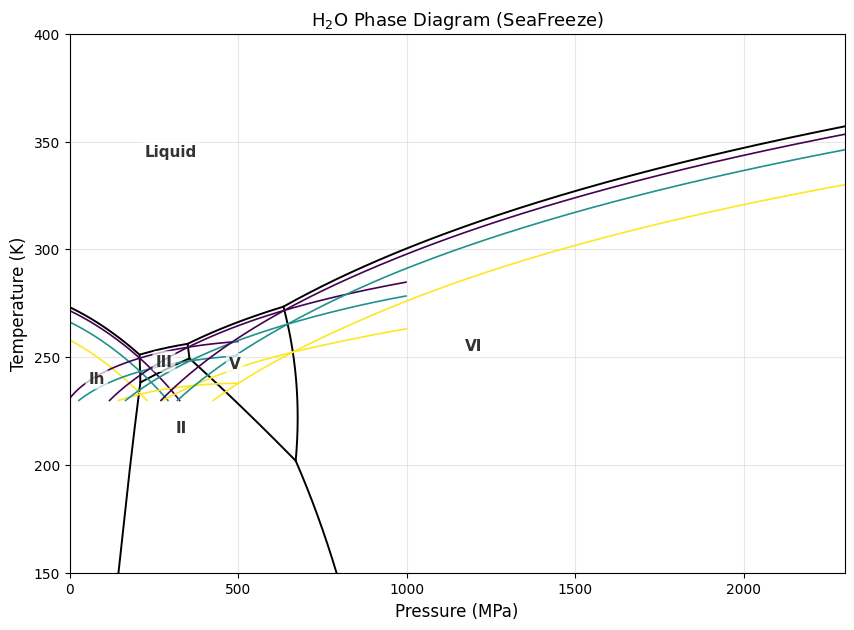

In [14]:
fig = sf.wpd(show_meta=False, phase_labels=True,
             solute='NaCl', m=[0.5, 2.0, 4.0])
display(fig); plt.close(fig)

## 6. `rho2P` — pressure from density and temperature

Inverts the EOS so that `rho(P, T) == rho_target`. Returns pressure in MPa
(`NaN` where no solution exists).

**(a) Scalar, (b) scatter vector, (c) NaClaq with molality**

In [15]:
# (a) compressed liquid water -> a few hundred MPa
print("water1, 1100 kg/m^3 @ 300 K -> P =",
      np.round(sf.rho2P(1100.0, 300.0, 'water1'), 2), "MPa")

# (b) ice VI at several (rho, T) points
P_vec = sf.rho2P([1310., 1350., 1390.], [255., 260., 265.], 'VI')
print("ice VI scatter -> P =", np.round(P_vec, 2), "MPa")

# (c) NaClaq at 1 mol/kg
print("NaClaq, 1050 kg/m^3 @ 300 K, m=1 -> P =",
      np.round(sf.rho2P(1050.0, 300.0, 'NaClaq', m=1.0), 2), "MPa")

water1, 1100 kg/m^3 @ 300 K -> P = 299.57 MPa
ice VI scatter -> P = [ 369.14  841.46 1391.33] MPa
NaClaq, 1050 kg/m^3 @ 300 K, m=1 -> P = 35.65 MPa


**(d) Round-trip check: `getProp` → `rho2P` recovers the input pressure**

In [16]:
PTm = np.empty(1, dtype=object)
PTm[0] = (500.0, 300.0)
rho = float(sf.getProp(PTm, 'water1', sf.seafreeze.defpath, 'rho').rho.flat[0])
P_rec = float(sf.rho2P(rho, 300.0, 'water1'))
print(f"input P = 500 MPa  ->  rho = {rho:.3f} kg/m^3  ->  recovered P = {P_rec:.3f} MPa")

input P = 500 MPa  ->  rho = 1148.533 kg/m^3  ->  recovered P = 500.000 MPa
